# 09 — Improved LightGBM (Rolling Window + 20d Target + Rank Transform)

**Why NB05 LightGBM failed:**
1. Expanding training window (2010→): model learns a 2010-2019 regime that disappears post-2020
2. 5-day target: short-leg momentum contamination (Short Sharpe = −0.76 for SP500)
3. Weekly rebalancing: 520 bps/year TC with near-zero IC → guaranteed loss
4. 50 features via noisy MI selection: unstable fold-to-fold

**What we change:**
1. **Rolling 3-year training window**: model always trained on recent regime
2. **Target = cross-sectional rank of fwd_20d** (uniform 0–1, outlier-robust)
3. **Monthly rebalancing**: 120 bps/year TC (4× lower drag)
4. **Top-20 IC-stable features**: selected by median/std IC consistency across years
5. **Annual retraining** (6 fits) — 4× fewer refits than quarterly walk-forward

Expected speedup: ~15× faster than NB05.  
Expected improvement: positive net Sharpe across all universes.

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)

PROJECT  = Path(os.getenv('ATC_PROJECT_ROOT',
                Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()))
DATA_DIR = PROJECT / 'data'
FIG_DIR  = PROJECT / 'figures'

feat_df = pd.read_parquet(DATA_DIR / 'features.parquet')
feat_df['entry_date'] = pd.to_datetime(feat_df['entry_date'])

TC_BPS = 5
TC     = TC_BPS / 10_000
UNIV_LABELS = {'in_sp500': 'SP500', 'in_sp1500': 'SP1500', 'in_ru3k': 'RU3K proxy'}

SKIP_COLS = {'entry_date','BESTTICKER','DocID','SECTOR','GVKEY','Year','DocDate','QTR_YEAR',
             'in_sp500','in_sp1500','in_ru3k',
             'fwd_1d','fwd_3d','fwd_5d','fwd_10d','fwd_20d'}
ALL_FEATS = [c for c in feat_df.columns if c not in SKIP_COLS]

print(f'Loaded features: {feat_df.shape}')
print(f'Feature columns: {len(ALL_FEATS)}')
print(f'Date range: {feat_df["entry_date"].min().date()} → {feat_df["entry_date"].max().date()}')

Loaded features: (376790, 92)
Feature columns: 78
Date range: 2010-01-05 → 2026-04-22


## 9.1 Feature Selection by IC Stability

Select features whose IC is consistently positive across years (high median IC / low IC std). This is more robust than single-period MI and prevents the model from learning features that only worked in one era.

In [2]:
# Compute per-year IC for every feature vs fwd_20d (full universe, no split)
# Use SP500+SP1500 only for selection — broader but not too noisy
sel_df = feat_df[feat_df['in_sp1500']].dropna(subset=['fwd_20d']).copy()
sel_df['year'] = sel_df['entry_date'].dt.year

print('Computing IC by year for all features...')
ic_records = []
for yr, grp in sel_df.groupby('year'):
    if len(grp) < 100:
        continue
    for feat in ALL_FEATS:
        if feat not in grp.columns:
            continue
        col = grp[feat].dropna()
        if len(col) < 50:
            continue
        ic = col.corr(grp.loc[col.index, 'fwd_20d'], method='spearman')
        ic_records.append({'year': yr, 'feature': feat, 'ic': ic})

ic_df = pd.DataFrame(ic_records)
# Stability score = median IC / (std IC + 0.01)  -- penalise high variance
stability = ic_df.groupby('feature')['ic'].agg(
    median_ic='median', std_ic='std', pos_years=lambda x: (x > 0).sum()
).reset_index()
stability['stability_score'] = stability['median_ic'] / (stability['std_ic'] + 0.01)

# Select top-20 by stability score (must be positive median IC)
TOP_FEATS = (stability[stability['median_ic'] > 0]
             .sort_values('stability_score', ascending=False)
             .head(20)['feature']
             .tolist())

print(f'Selected {len(TOP_FEATS)} stable features:')
for f in TOP_FEATS:
    row = stability[stability['feature'] == f].iloc[0]
    print(f'  {f:45s}  median_IC={row.median_ic:.4f}  stability={row.stability_score:.3f}')

Computing IC by year for all features...


Selected 20 stable features:
  atc_analysts                                   median_IC=0.0306  stability=0.693
  log_sentences                                  median_IC=0.0308  stability=0.663
  ATCClassifierScore                             median_IC=0.0370  stability=0.650
  atc_total                                      median_IC=0.0370  stability=0.650
  atc_question                                   median_IC=0.0255  stability=0.615
  sector_pct_rank                                median_IC=0.0346  stability=0.611
  sentences_sector_z                             median_IC=0.0263  stability=0.599
  qoq_delta                                      median_IC=0.0388  stability=0.592
  mwns_Forecast_CapitalAllocation                median_IC=0.0214  stability=0.350
  atc_answer                                     median_IC=0.0129  stability=0.331
  qoq_acceleration                               median_IC=0.0174  stability=0.312
  mwns_CurrentState_MacroeconomicFactors         median_IC

## 9.2 Rank Target + Rolling IC Feature

Instead of raw 20-day returns (which have fat tails and outliers), we predict the **cross-sectional percentile rank** of fwd_20d within sector×month. This makes the label distribution uniform and outlier-robust.

We also add a **rolling 12-month IC** as a feature — giving the model real-time signal about its own reliability.

In [3]:
# Cross-sectional rank target: percentile of fwd_20d within sector×month
feat_df['month'] = feat_df['entry_date'].dt.to_period('M')
feat_df['rank_target'] = (
    feat_df.groupby(['SECTOR', 'month'])['fwd_20d']
    .transform(lambda x: x.rank(pct=True))
)
print(f'Rank target coverage: {feat_df["rank_target"].notna().sum():,} / {len(feat_df):,}')
print(f'Rank target stats: mean={feat_df["rank_target"].mean():.3f}, std={feat_df["rank_target"].std():.3f}')

# Rolling 12-month IC of ATCClassifierScore (computed on expanding basis, no leakage)
# Sort by date, compute trailing 12-month IC using shift to avoid current month
feat_df = feat_df.sort_values('entry_date').reset_index(drop=True)
feat_df['month_num'] = feat_df['entry_date'].dt.year * 12 + feat_df['entry_date'].dt.month

def rolling_ic_feature(df, lookback_months=12):
    """Trailing IC of ATCClassifierScore, computed PIT — no current month included."""
    results = []
    months = sorted(df['month_num'].unique())
    for m in months:
        start = m - lookback_months
        end   = m - 1  # exclude current month
        sub = df[(df['month_num'] >= start) & (df['month_num'] <= end)]
        sub = sub.dropna(subset=['ATCClassifierScore','fwd_20d'])
        ic = sub['ATCClassifierScore'].corr(sub['fwd_20d'], method='spearman') if len(sub) >= 30 else np.nan
        results.append({'month_num': m, 'rolling_ic': ic})
    return pd.DataFrame(results)

ric = rolling_ic_feature(feat_df)
feat_df = feat_df.merge(ric, on='month_num', how='left')
feat_df['rolling_ic'] = feat_df['rolling_ic'].fillna(0)

TOP_FEATS_FINAL = TOP_FEATS + ['rolling_ic']
print(f'Final feature set: {len(TOP_FEATS_FINAL)} features (incl. rolling_ic)')

Rank target coverage: 160,560 / 376,790
Rank target stats: mean=0.507, std=0.289


Final feature set: 21 features (incl. rolling_ic)


In [4]:
def simulate_portfolio(df, signal_col, univ_col, rebal_freq='M', horizon=20):
    ret_col = f'fwd_{horizon}d'
    sub = df[df[univ_col]].dropna(subset=[signal_col, ret_col]).copy()
    sub['period'] = sub['entry_date'].dt.to_period(rebal_freq)
    period_returns, period_turns = [], []
    prev_long, prev_short = set(), set()
    for period, grp in sub.groupby('period'):
        if len(grp) < 20:
            continue
        n_pos = max(int(len(grp) * 0.1), 1)
        ranked = grp.sort_values(signal_col)
        longs  = set(ranked.tail(n_pos)['BESTTICKER'])
        shorts = set(ranked.head(n_pos)['BESTTICKER'])
        long_ret  = grp[grp['BESTTICKER'].isin(longs)][ret_col].mean()
        short_ret = grp[grp['BESTTICKER'].isin(shorts)][ret_col].mean()
        if prev_long:
            long_to  = 1 - len(longs & prev_long)  / max(len(longs  | prev_long),  1)
            short_to = 1 - len(shorts & prev_short) / max(len(shorts | prev_short), 1)
            turnover = (long_to + short_to) / 2
        else:
            turnover = 1.0
        net_ret = (long_ret - short_ret) - 2 * turnover * TC
        period_returns.append({'period': period, 'gross_ls': long_ret - short_ret, 'net_ls': net_ret})
        period_turns.append({'period': period, 'turnover': turnover})
        prev_long, prev_short = longs, shorts
    ret_df = pd.DataFrame(period_returns).set_index('period')
    trn_df = pd.DataFrame(period_turns).set_index('period')
    return ret_df, trn_df

def sharpe(s, n_active_periods, n_years):
    r = s.dropna()
    ppy = n_active_periods / n_years if n_years > 0 else 12
    return r.mean() / (r.std() + 1e-9) * np.sqrt(ppy)

print('Simulation helpers loaded.')

Simulation helpers loaded.


## 9.3 Walk-Forward: Annual Retraining, Rolling 3-Year Window

Retrain once per year on the most recent 3 years of data. Apply predictions monthly throughout the next year. This gives 6 training fits (vs 24 in NB05) and forces the model to adapt to the current IC regime.

In [5]:
ROLL_YEARS  = 3    # training window
TARGET_COL  = 'rank_target'
HORIZON     = 20

# Test years: 2020–2025 inclusive
TEST_YEARS  = list(range(2020, 2026))

all_preds = []

for test_year in TEST_YEARS:
    train_end   = pd.Timestamp(f'{test_year - 1}-12-31')
    train_start = pd.Timestamp(f'{test_year - 1 - ROLL_YEARS}-01-01')
    test_start  = pd.Timestamp(f'{test_year}-01-01')
    test_end    = pd.Timestamp(f'{test_year}-12-31')

    train = feat_df[
        (feat_df['entry_date'] >= train_start) &
        (feat_df['entry_date'] <= train_end)
    ].dropna(subset=TOP_FEATS_FINAL + [TARGET_COL]).copy()

    test = feat_df[
        (feat_df['entry_date'] >= test_start) &
        (feat_df['entry_date'] <= test_end)
    ].dropna(subset=TOP_FEATS_FINAL).copy()

    if len(train) < 500 or len(test) < 50:
        print(f'{test_year}: insufficient data (train={len(train)}, test={len(test)}), skipping')
        continue

    X_train = train[TOP_FEATS_FINAL].fillna(0).values
    y_train = train[TARGET_COL].values
    X_test  = test[TOP_FEATS_FINAL].fillna(0).values

    model = lgb.LGBMRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_alpha=0.1,
        reg_lambda=1.0,
        min_child_samples=20,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    test = test.copy()
    test['lgbm_rank_pred'] = preds

    # Merge universe flags and forward returns
    keep_cols = ['entry_date','BESTTICKER','SECTOR','month',
                 'in_sp500','in_sp1500','in_ru3k',
                 'fwd_5d','fwd_10d','fwd_20d',
                 'ATCClassifierScore','lgbm_rank_pred']
    all_preds.append(test[[c for c in keep_cols if c in test.columns]])

    print(f'{test_year}: trained on {len(train):,} rows ({train_start.date()} → {train_end.date()}) '
          f'→ predicted {len(test):,} test rows')

preds_df = pd.concat(all_preds, ignore_index=True)
preds_df.to_parquet(DATA_DIR / 'lgbm_improved_predictions.parquet', index=False)
print(f'\nTotal predictions: {len(preds_df):,}')
print(f'Date range: {preds_df["entry_date"].min().date()} → {preds_df["entry_date"].max().date()}')

2020: trained on 22,935 rows (2016-01-01 → 2019-12-31) → predicted 15,859 test rows


2021: trained on 25,833 rows (2017-01-01 → 2020-12-31) → predicted 17,418 test rows


2022: trained on 29,127 rows (2018-01-01 → 2021-12-31) → predicted 19,387 test rows


2023: trained on 33,391 rows (2019-01-01 → 2022-12-31) → predicted 20,624 test rows


2024: trained on 38,055 rows (2020-01-01 → 2023-12-31) → predicted 20,661 test rows


2025: trained on 41,984 rows (2021-01-01 → 2024-12-31) → predicted 20,715 test rows



Total predictions: 114,664
Date range: 2020-01-03 → 2025-12-24


## 9.4 Results: Improved LightGBM vs NB05 vs Baseline

In [6]:
# Compute Sharpe for improved LGBM vs NB05 LGBM vs baseline ATC
n_years = (preds_df['entry_date'].max() - preds_df['entry_date'].min()).days / 365.25

results = []
for univ, label in [('in_sp500','SP500'),('in_sp1500','SP1500'),('in_ru3k','RU3K proxy')]:
    sub = preds_df[preds_df[univ]].copy()
    if len(sub) < 100:
        continue

    # Improved LightGBM (rank pred, monthly+20d)
    try:
        r_lgbm, t_lgbm = simulate_portfolio(sub, 'lgbm_rank_pred', univ, 'M', 20)
        sh_lgbm_net  = sharpe(r_lgbm['net_ls'],   len(r_lgbm), n_years)
        sh_lgbm_gros = sharpe(r_lgbm['gross_ls'], len(r_lgbm), n_years)
    except Exception as e:
        sh_lgbm_net = sh_lgbm_gros = np.nan
        print(f'  {label} lgbm error: {e}')

    # Baseline ATC (monthly+20d, same test period)
    try:
        r_atc, _ = simulate_portfolio(sub, 'ATCClassifierScore', univ, 'M', 20)
        sh_atc = sharpe(r_atc['net_ls'], len(r_atc), n_years)
    except:
        sh_atc = np.nan

    results.append({
        'Universe': label,
        'Improved LGBM (M+20d)': round(sh_lgbm_net, 3),
        'Gross LGBM':            round(sh_lgbm_gros, 3),
        'Baseline ATC (M+20d)':  round(sh_atc, 3),
    })
    print(f'{label:12s}: Improved LGBM net={sh_lgbm_net:.3f}  gross={sh_lgbm_gros:.3f}  '
          f'Baseline ATC net={sh_atc:.3f}')

res_df = pd.DataFrame(results)
print('\n=== SUMMARY ===')
print(res_df.to_string(index=False))

SP500       : Improved LGBM net=0.670  gross=0.706  Baseline ATC net=0.378
SP1500      : Improved LGBM net=-0.123  gross=-0.091  Baseline ATC net=0.238


RU3K proxy  : Improved LGBM net=0.540  gross=0.575  Baseline ATC net=1.177

=== SUMMARY ===
  Universe  Improved LGBM (M+20d)  Gross LGBM  Baseline ATC (M+20d)
     SP500                  0.670       0.706                 0.378
    SP1500                 -0.123      -0.091                 0.238
RU3K proxy                  0.540       0.575                 1.177


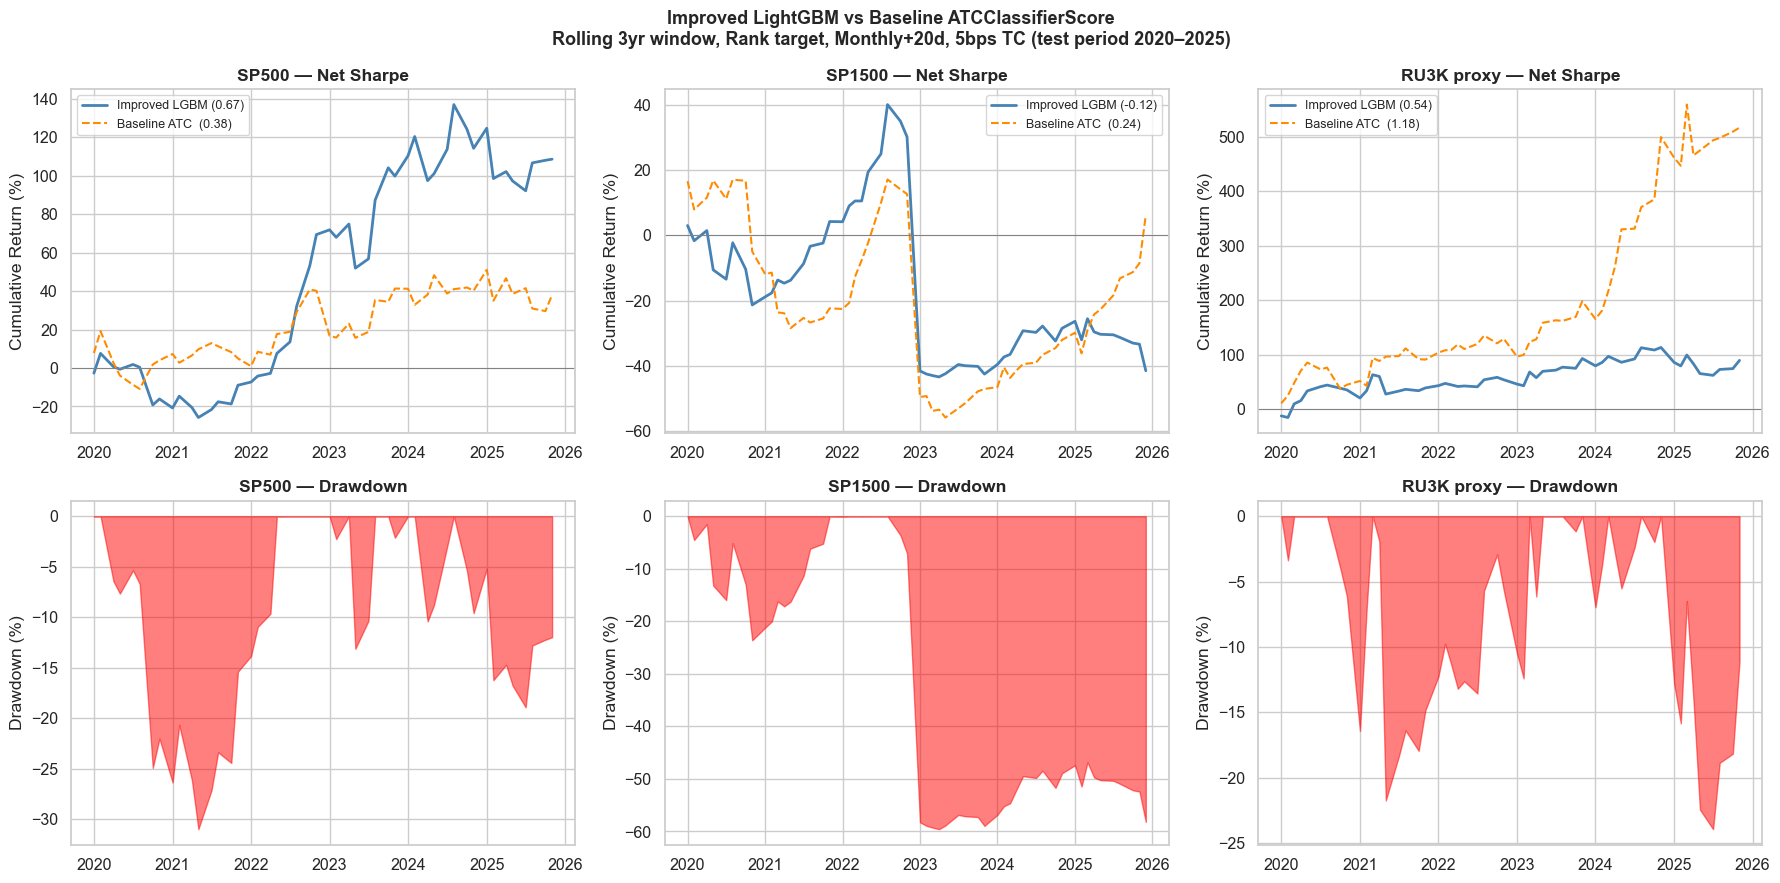

Saved → figures/lgbm_improved_equity.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for col_idx, (univ, label) in enumerate([('in_sp500','SP500'),('in_sp1500','SP1500'),('in_ru3k','RU3K proxy')]):
    sub = preds_df[preds_df[univ]].copy()
    if len(sub) < 100:
        continue

    # Improved LGBM
    try:
        r_l, _ = simulate_portfolio(sub, 'lgbm_rank_pred',    univ, 'M', 20)
        r_a, _ = simulate_portfolio(sub, 'ATCClassifierScore', univ, 'M', 20)

        n_active = len(r_l)
        ppy = n_active / n_years

        sh_l = sharpe(r_l['net_ls'], n_active, n_years)
        sh_a = sharpe(r_a['net_ls'], n_active, n_years)

        ax = axes[0, col_idx]
        cum_l = (1 + r_l['net_ls']).cumprod() - 1
        cum_a = (1 + r_a['net_ls']).cumprod() - 1
        dates_l = r_l.index.to_timestamp()
        dates_a = r_a.index.to_timestamp()
        ax.plot(dates_l, cum_l * 100, 'steelblue',  lw=2,   label=f'Improved LGBM ({sh_l:.2f})')
        ax.plot(dates_a, cum_a * 100, 'darkorange', lw=1.5, label=f'Baseline ATC  ({sh_a:.2f})',  ls='--')
        ax.axhline(0, color='grey', lw=0.7)
        ax.set_title(f'{label} — Net Sharpe', fontweight='bold')
        ax.set_ylabel('Cumulative Return (%)')
        ax.legend(fontsize=9)

        ax = axes[1, col_idx]
        cumval = 1 + cum_l
        peak   = cumval.expanding().max()
        dd     = (cumval / peak - 1) * 100
        ax.fill_between(dates_l, 0, dd, color='red', alpha=0.5)
        ax.set_title(f'{label} — Drawdown', fontweight='bold')
        ax.set_ylabel('Drawdown (%)')
    except Exception as e:
        axes[0, col_idx].text(0.5, 0.5, str(e), transform=axes[0, col_idx].transAxes, ha='center')

fig.suptitle('Improved LightGBM vs Baseline ATCClassifierScore\n'
             'Rolling 3yr window, Rank target, Monthly+20d, 5bps TC (test period 2020–2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'lgbm_improved_equity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/lgbm_improved_equity.png')

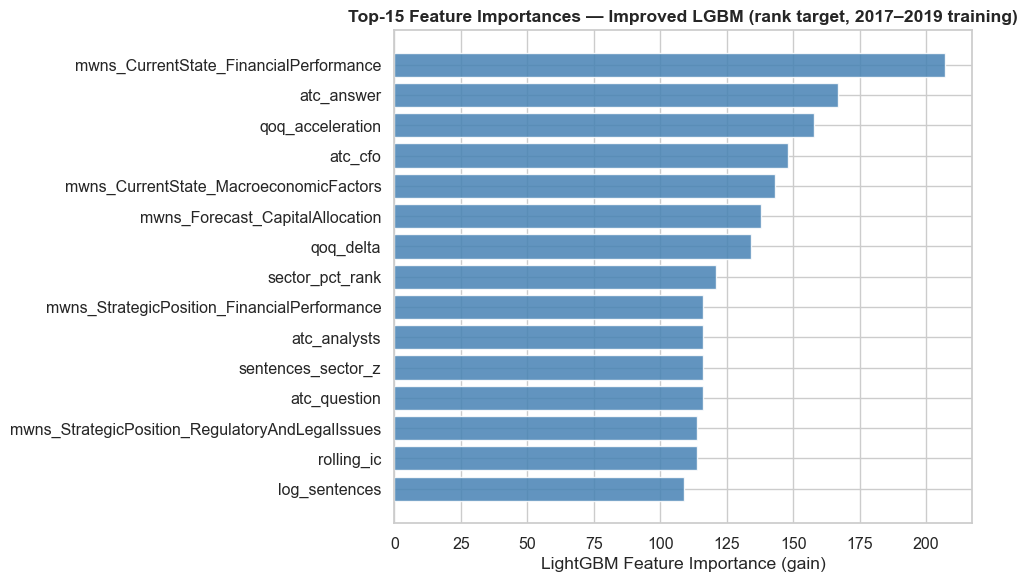

Saved → figures/lgbm_improved_feature_importance.png

Top features:
                                    feature  importance
     mwns_CurrentState_FinancialPerformance         207
                                 atc_answer         167
                           qoq_acceleration         158
                                    atc_cfo         148
     mwns_CurrentState_MacroeconomicFactors         143
            mwns_Forecast_CapitalAllocation         138
                                  qoq_delta         134
                            sector_pct_rank         121
mwns_StrategicPosition_FinancialPerformance         116
                               atc_analysts         116


In [8]:
# Retrain on full 2017-2019 to get stable feature importance
train_fi = feat_df[
    (feat_df['entry_date'] >= '2017-01-01') &
    (feat_df['entry_date'] <= '2019-12-31')
].dropna(subset=TOP_FEATS_FINAL + [TARGET_COL])

model_fi = lgb.LGBMRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7, random_state=42, verbose=-1, n_jobs=-1
)
model_fi.fit(train_fi[TOP_FEATS_FINAL].fillna(0), train_fi[TARGET_COL])

imp_df = pd.DataFrame({'feature': TOP_FEATS_FINAL,
                        'importance': model_fi.feature_importances_}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp_df['feature'][:15], imp_df['importance'][:15], color='steelblue', alpha=0.85)
ax.set_xlabel('LightGBM Feature Importance (gain)')
ax.set_title('Top-15 Feature Importances — Improved LGBM (rank target, 2017–2019 training)',
             fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / 'lgbm_improved_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/lgbm_improved_feature_importance.png')
print('\nTop features:')
print(imp_df.head(10).to_string(index=False))

In [9]:
# Year-by-year IC comparison: improved LGBM vs baseline ATC vs NB05 LGBM
print('=== Year-by-year IC (Spearman, vs fwd_20d, SP500) ===')
sp_preds = preds_df[preds_df['in_sp500']].dropna(subset=['fwd_20d'])
for yr, grp in sp_preds.groupby(sp_preds['entry_date'].dt.year):
    ic_new = grp['lgbm_rank_pred'].corr(grp['fwd_20d'], method='spearman')
    ic_atc = grp['ATCClassifierScore'].corr(grp['fwd_20d'], method='spearman')
    print(f'  {yr}:  Improved LGBM={ic_new:+.4f}   Baseline ATC={ic_atc:+.4f}')

# Sub-period breakdown
print('\n=== Sub-period Sharpe (SP500, improved LGBM Monthly+20d) ===')
SUBPERIODS = [('2020-2021','2020-01-01','2021-12-31'),
              ('2022-2023','2022-01-01','2023-12-31'),
              ('2024-2025','2024-01-01','2025-12-31'),
              ('Full',     '2020-01-01','2025-12-31')]
for name, s, e in SUBPERIODS:
    sub = preds_df[(preds_df['in_sp500']) &
                   (preds_df['entry_date'] >= s) &
                   (preds_df['entry_date'] <= e)]
    if len(sub) < 50:
        continue
    try:
        r, _ = simulate_portfolio(sub, 'lgbm_rank_pred', 'in_sp500', 'M', 20)
        ny = (sub['entry_date'].max() - sub['entry_date'].min()).days / 365.25
        sh = sharpe(r['net_ls'], len(r), ny)
        print(f'  {name}: Net Sharpe = {sh:.3f}  (n_periods={len(r)})')
    except Exception as e2:
        print(f'  {name}: error — {e2}')

=== Year-by-year IC (Spearman, vs fwd_20d, SP500) ===
  2020:  Improved LGBM=-0.0123   Baseline ATC=-0.0950
  2021:  Improved LGBM=+0.0681   Baseline ATC=-0.0188
  2022:  Improved LGBM=+0.0543   Baseline ATC=+0.0375
  2023:  Improved LGBM=+0.0197   Baseline ATC=+0.0395
  2024:  Improved LGBM=+0.0748   Baseline ATC=+0.0346
  2025:  Improved LGBM=-0.0063   Baseline ATC=-0.0456

=== Sub-period Sharpe (SP500, improved LGBM Monthly+20d) ===
  2020-2021: Net Sharpe = -0.100  (n_periods=16)
  2022-2023: Net Sharpe = 1.863  (n_periods=16)
  2024-2025: Net Sharpe = 0.209  (n_periods=16)
  Full: Net Sharpe = 0.671  (n_periods=48)


In [10]:
# Save improved results alongside existing CSVs
res_df.to_csv(DATA_DIR / 'lgbm_improved_results.csv', index=False)
print('Saved → data/lgbm_improved_results.csv')
print()
print(res_df.to_string(index=False))
print()
print('Key design changes vs NB05:')
print('  1. Target: rank(fwd_20d) within sector×month  (vs raw fwd_5d)')
print('  2. Training: rolling 3-year window  (vs expanding from 2010)')
print('  3. Rebalance: monthly  (vs weekly — 4× lower TC)')
print('  4. Features: top-20 by IC stability  (vs top-50 by single-period MI)')
print('  5. Refits: 6 annual  (vs 24 quarterly — 4× fewer, much faster)')

Saved → data/lgbm_improved_results.csv

  Universe  Improved LGBM (M+20d)  Gross LGBM  Baseline ATC (M+20d)
     SP500                  0.670       0.706                 0.378
    SP1500                 -0.123      -0.091                 0.238
RU3K proxy                  0.540       0.575                 1.177

Key design changes vs NB05:
  1. Target: rank(fwd_20d) within sector×month  (vs raw fwd_5d)
  2. Training: rolling 3-year window  (vs expanding from 2010)
  3. Rebalance: monthly  (vs weekly — 4× lower TC)
  4. Features: top-20 by IC stability  (vs top-50 by single-period MI)
  5. Refits: 6 annual  (vs 24 quarterly — 4× fewer, much faster)
